In [1]:
# Scripts imports
import source.processing as processing
import source.analyze as analyze

> Dir `data_imports` already exists.
> Dir `data_processed` already exists.
> Dir `lpa_input` already exists.
> Dir `lpa_results` already exists.


---
### `Substitution Survival` Analysis
## Part 1 - Preprocessing
In this part we will 
1. Import the raw data from the MySQL server
2. Preprocess the data into mutation dataframe
3. Create suitible input for the LPA algorithm

In [5]:
### Preparing the data for the LPA analysis - Substitution Survival
# 1. Creating the LPA preprocessing object, defining the analysis metric.
lpa_preprocessing = processing.lpa_prep(metric = "substitution_survival") 

# 2. Importing the data from the mysql server (if required).
lpa_preprocessing.import_tables()

# 2. Process the raw sql imports to the 
lpa_preprocessing.process_tables(metadata_columns="collection_time_point_relative,cell_subset",    # Metadata which will be collected from the metadata table
                                metadata_rename="time_point,ab_target")                            # Renaming of the metadata columns

# 3. Removing every file (to free space) except the file required for the lpa document construction
#lpa_preprocessing.purge_data()

# 4. Creating the required document for the LPA analysis
#    Can load the input data as csv or as pd.DataFrame object - can modify column name and data as see fit
# Creating the required document for the LPA analysis
lpa_preprocessing.create_documents(document = "ab_target,time_point,subject_id",   # Order by which data data will be grouped by
                                    overwrite = False                              # Overwite current lpa input file (if exsits)?
                                    )                             

> Dir `data_imports\covid_vaccine_new-substitution_survival` already exists.
> Dir `data_processed\covid_vaccine_new-substitution_survival` already exists.
> Dir `lpa_input\covid_vaccine_new-substitution_survival` already exists.
> Dir `lpa_results\covid_vaccine_new-substitution_survival` already exists.
> `mut_df.csv` exists, no need to import file. use pruge_file() if needed.
> `mut_df.csv` exists, no need to import file. use pruge_file() if needed.
> `lpa_input.csv` exsits and overwrite = False. Wont create new file.


---
## Part 2 - LPA Analysis

In this part we will 
1. Use the `lpa_input.csv` that was created during part 1.
2. Create signaure dataframe.
3. Visulize the signatures via heatmap.
4. Perform PCA and visulize the results in scatterplot.

In [6]:
# Initiating the LPA algorithm object
lpa_mutsub = analyze.lpa_analysis(metric="substitution_survival",  # metric on which the analysis will be performed
                                  min_treshold = 100,              # Minmal number of clones required in entity (document)
                                  drop_rare_elements= True,        # To drop rare element?
                                  element_treshold = 10,           # Minimal number of occurnces per element required.
                                  entity_treshold = 0.9            # Minimal existance of elements in ettity retuired.
                                  )          

> The following document havn't met the treshold (100):
                     document  frequency_in_document
18  Spike+ Mem B.1 baseline.6                     88
19  Spike+ Mem B.1 baseline.7                      3
24     Spike+ Mem B.2 weeks.7                     29
26     Spike+ Mem B.4 weeks.4                     63


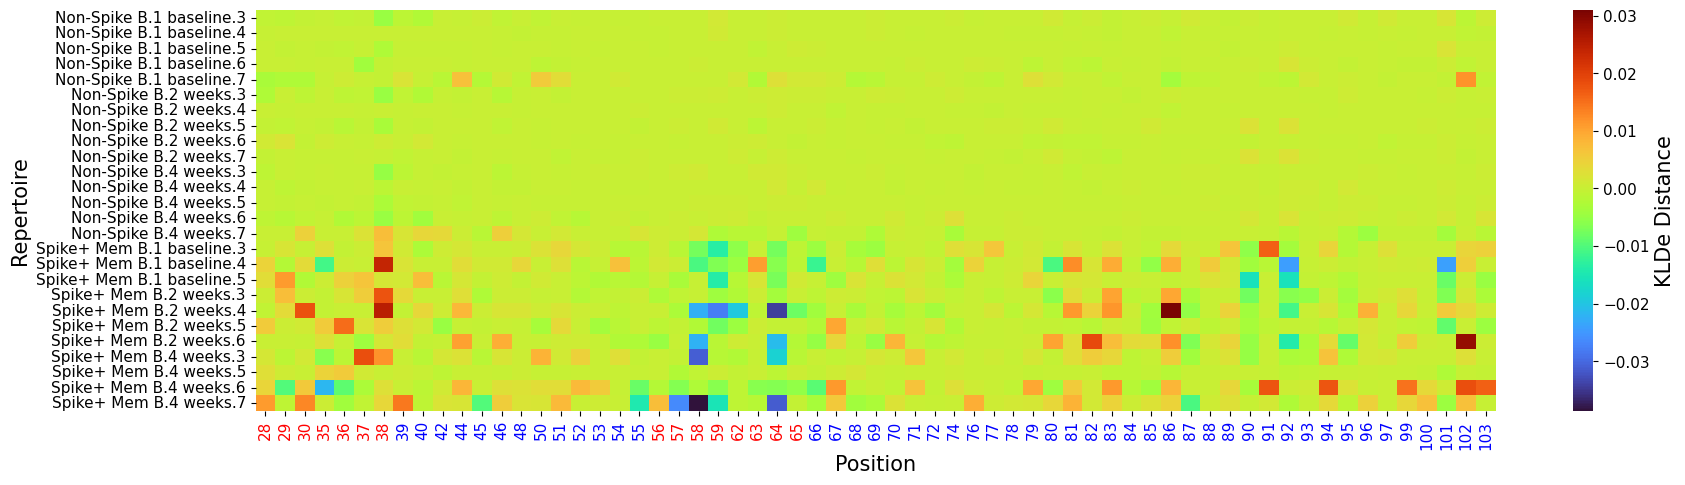

In [7]:
#Plotting heatmap of the domain KLDe distances
lpa_mutsub.heatmap()

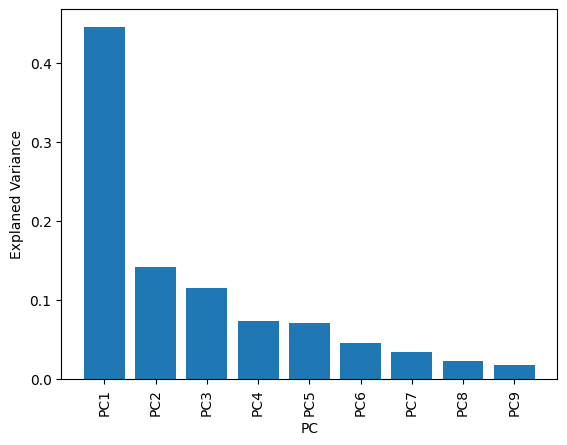

In [8]:
# Perform PCA and plot scatterplot
pca_mutsub = lpa_mutsub.pca()

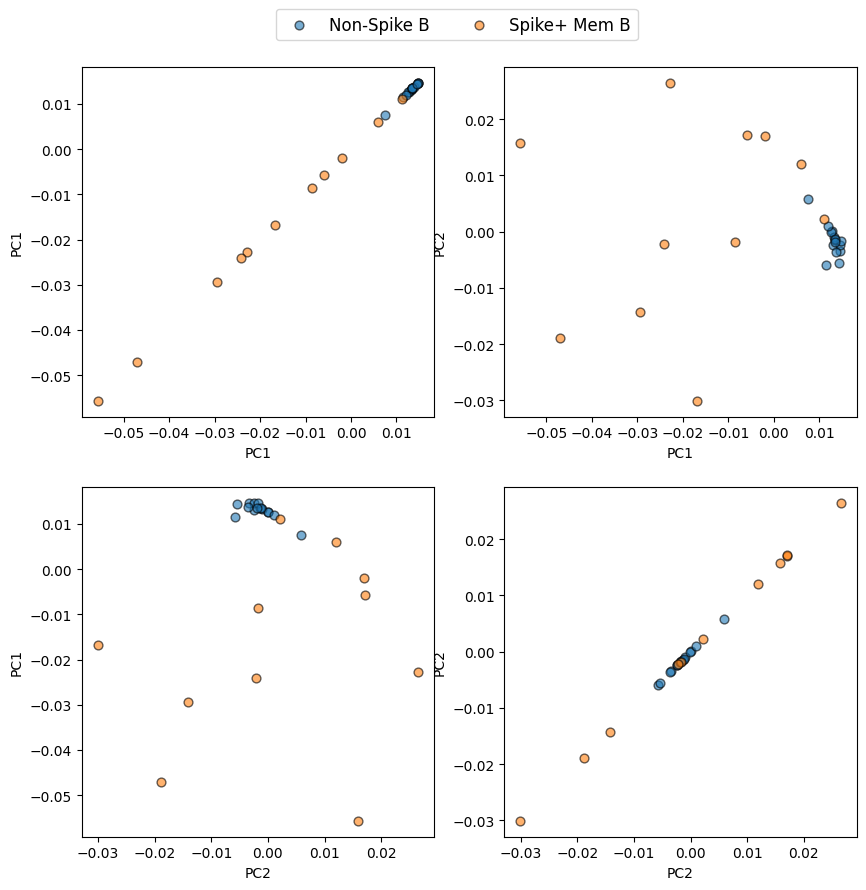

In [9]:
# Using scatter plot to visualize the PCA analysis
# Using scatter plot to visualize the PCA analysis
lpa_mutsub.pca_scatter(n_pcs=2,         # The number of PC object to be visualized
                       label_index=0    # Index of label on which the data will be colored by
                       )   

---
### `Trimer Usage` Analysis
## Part 1 - Preprocessing
In this part we will 
1. Import the raw data from the MySQL server
2. Preprocess the data into mutation dataframe
3. Create suitible input for the LPA algorithm

In [10]:
### Preparing the data for the LPA analysis - Trimers Usage
# 1. Creating the LPA preprocessing object, defining the analysis metric.
lpa_preprocessing = processing.lpa_prep(metric = "trimers_usage")

# 2. Importing the data from the mysql server (if required).
lpa_preprocessing.import_tables()

# 2. Process the raw sql imports to the 
lpa_preprocessing.process_tables(metadata_columns="collection_time_point_relative,cell_subset",   # Metadata which will be collected from the metadata table
                                 metadata_rename="time_point,ab_target"                           # Renaming of the metadata columns
                                 )                          

# 3. Removing every file (to free space) except the file required for the lpa document construction
#lpa_preprocessing.purge_data()

# 4. Creating the required document for the LPA analysis
#    Can load the input data as csv or as pd.DataFrame object - can modify column name and data as see fit
# Creating the required document for the LPA analysis
lpa_preprocessing.create_documents(document = "ab_target,time_point,subject_id",    # Order by which data data will be grouped by
                                   overwrite = False                                # Overwite current lpa input file (if exsits)?
                                   )                                  

> Dir `data_imports\covid_vaccine_new-trimers_usage` already exists.
> Dir `data_processed\covid_vaccine_new-trimers_usage` already exists.
> Dir `lpa_input\covid_vaccine_new-trimers_usage` already exists.
> Dir `lpa_results\covid_vaccine_new-trimers_usage` already exists.
> `cleaned_seqs.csv` exists, no need to import file. use pruge_file() if needed.
> `cleaned_seqs.csv` exists, no need to import file. use pruge_file() if needed.
> `lpa_input.csv` exsits and overwrite = False. Wont create new file.


---
## Part 2 - LPA Analysis

In this part we will 
1. Use the `lpa_input.csv` that was created during part 1.
2. Create signaure dataframe.
3. Visulize the signatures via heatmap.
4. Perform PCA and visulize the results in scatterplot.

In [10]:
# Initiating the LPA algorithm object
lpa_mutsub = analyze.lpa_analysis(metric="trimers_usage",  # metric on which the analysis will be performed
                                  min_treshold = 100,              # Minmal number of clones required in entity (document)
                                  drop_rare_elements= False,        # To drop rare element?
                                  element_treshold = 10,           # Minimal number of occurnces per element required.
                                  entity_treshold = 0.9            # Minimal existance of elements in ettity retuired.
                                  ) 

> The following document havn't met the treshold (100):
                  document  frequency_in_document
19  Spike+MemB.1baseline.7                      2
24     Spike+MemB.2weeks.7                     41
26     Spike+MemB.4weeks.4                     53


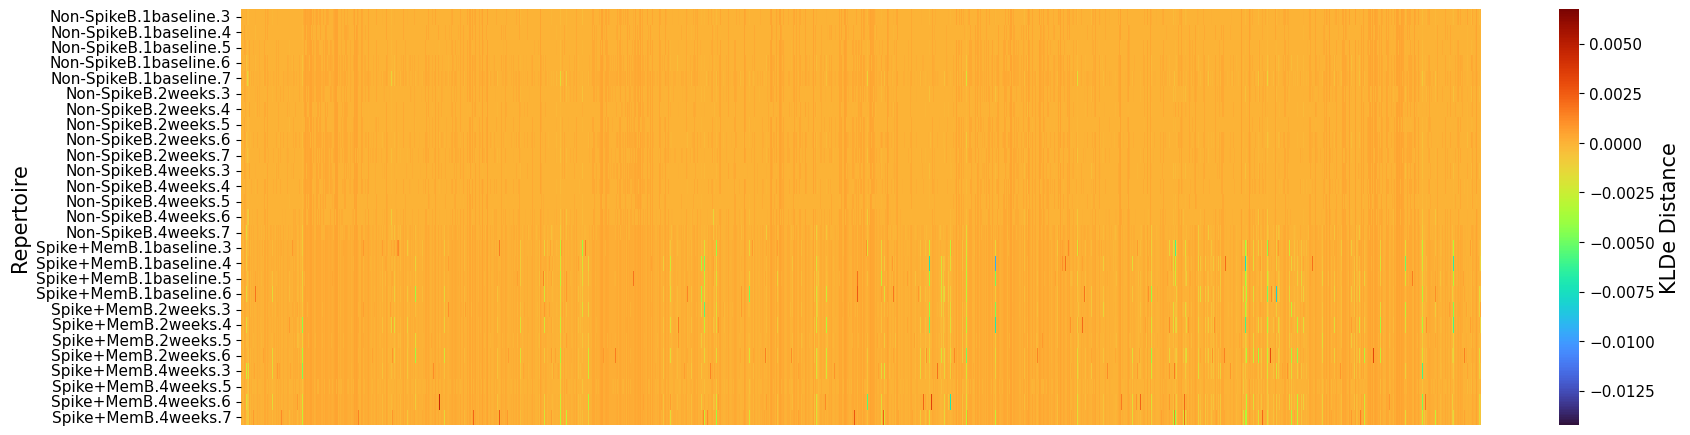

In [11]:
#Plotting heatmap of the domain KLDe distances
lpa_mutsub.heatmap()

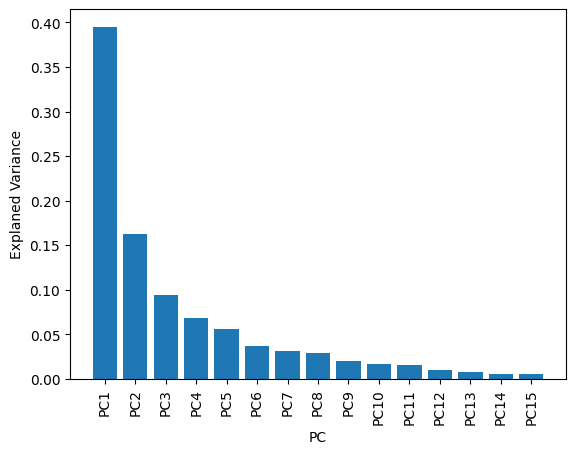

In [12]:
# Perform PCA and plot scatterplot
pca_mutsub = lpa_mutsub.pca()

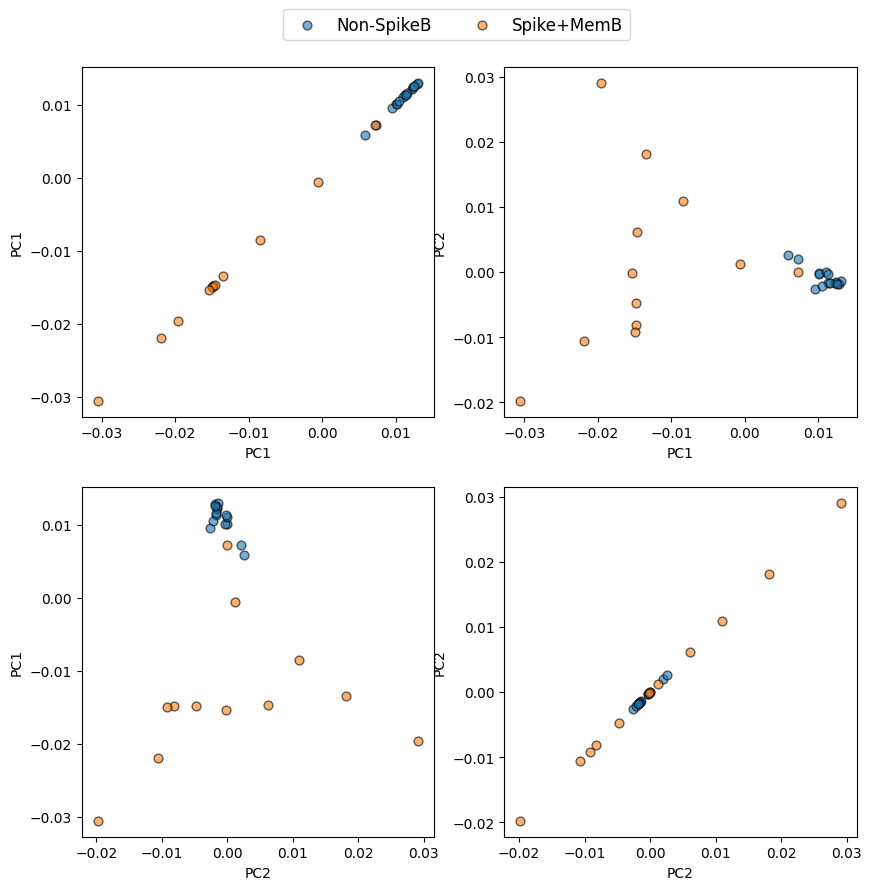

In [13]:
# Using scatter plot to visualize the PCA analysis
lpa_mutsub.pca_scatter(n_pcs=2,         # The number of PC object to be visualized
                       label_index=0    # Index of label on which the data will be colored by
                       )   